# HW3: Deep Neural Network from Scratch

Binary classification of MNIST digit 5 (label 1) vs digit 6 (label 0).

Network: 784 input, 200 hidden with ReLU, 1 output with Sigmoid.

No nn.Linear, no autograd, no optimizer, no DataLoader, no NumPy, no TensorFlow.

In [1]:
import csv
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)
torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

## Load data

In [2]:
def load_csv(path):
    features, labels = [], []
    with open(path) as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            labels.append(float(row[0]))
            features.append([float(v) for v in row[1:]])
    X = torch.tensor(features) / 255.0
    y = torch.tensor(labels).view(-1, 1)
    return X, y

X_train, y_train = load_csv("mnist_train_binary.csv")
X_test, y_test = load_csv("mnist_test_binary.csv")

print("X_train:", tuple(X_train.shape), "y_train:", tuple(y_train.shape))
print("X_test:", tuple(X_test.shape), "y_test:", tuple(y_test.shape))

X_train: (11339, 784) y_train: (11339, 1)
X_test: (1850, 784) y_test: (1850, 1)


## 1. Build the network

Sigmoid and ReLU defined from scratch.

$$\sigma(z) = \frac{1}{1 + \exp(-z)} \qquad ReLU(z) = \max(0, z)$$

In [3]:
def sigmoid(z):
    return 1.0 / (1.0 + torch.exp(-z))

def relu(z):
    return torch.clamp(z, min=0.0)

def relu_derivative(z):
    return (z > 0).float()

Weights are plain tensors. W1 uses He initialization, W2 uses Xavier initialization.

In [4]:
def initialize_parameters(n_in=784, n_h=200, n_out=1):
    return {
        "W1": torch.randn(n_in, n_h) * (2.0 / n_in) ** 0.5,
        "b1": torch.zeros(1, n_h),
        "W2": torch.randn(n_h, n_out) * (1.0 / n_h) ** 0.5,
        "b2": torch.zeros(1, n_out),
    }

Forward pass:

$$Z^{[1]} = X W^{[1]} + b^{[1]} \qquad A^{[1]} = ReLU(Z^{[1]})$$
$$Z^{[2]} = A^{[1]} W^{[2]} + b^{[2]} \qquad A^{[2]} = \sigma(Z^{[2]}) = \hat{y}$$

In [5]:
def forward(X, params):
    Z1 = X @ params["W1"] + params["b1"]
    A1 = relu(Z1)
    Z2 = A1 @ params["W2"] + params["b2"]
    A2 = sigmoid(Z2)
    cache = {"X": X, "Z1": Z1, "A1": A1, "A2": A2}
    return A2, cache

## 2. Loss, accuracy and backward propagation

$$J = -\frac{1}{m}\sum_{i=1}^{m}[y^i \log(\hat{y}^i) + (1-y^i)\log(1-\hat{y}^i)]$$

In [6]:
def binary_cross_entropy(y, y_hat):
    eps = 1e-8
    return -torch.mean(y * torch.log(y_hat + eps) + (1 - y) * torch.log(1 - y_hat + eps))

def accuracy(y, y_hat):
    return torch.mean(((y_hat >= 0.5).float() == y).float())

Gradients:

$$dZ^{[2]} = \frac{1}{m}(A^{[2]} - y) \qquad dW^{[2]} = A^{[1]T} dZ^{[2]} \qquad db^{[2]} = \sum_i dZ^{[2]}_i$$
$$dZ^{[1]} = (dZ^{[2]} W^{[2]T}) \odot ReLU'(Z^{[1]}) \qquad dW^{[1]} = X^{T} dZ^{[1]} \qquad db^{[1]} = \sum_i dZ^{[1]}_i$$

In [7]:
def backward(y, cache, params):
    m = y.shape[0]
    X, Z1, A1, A2 = cache["X"], cache["Z1"], cache["A1"], cache["A2"]

    dZ2 = (A2 - y) / m
    dW2 = A1.t() @ dZ2
    db2 = dZ2.sum(dim=0, keepdim=True)

    dZ1 = (dZ2 @ params["W2"].t()) * relu_derivative(Z1)
    dW1 = X.t() @ dZ1
    db1 = dZ1.sum(dim=0, keepdim=True)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

def update_parameters(params, grads, learning_rate):
    for key in params:
        params[key] = params[key] - learning_rate * grads[key]
    return params

## 3. Training

Gradient descent on the full training set. Learning rate 0.5, 300 epochs.

In [8]:
learning_rate = 0.5
epochs = 300

params = initialize_parameters()
history = {"epoch": [], "train_acc": [], "test_acc": []}

for epoch in range(1, epochs + 1):
    y_hat, cache = forward(X_train, params)
    loss = binary_cross_entropy(y_train, y_hat)
    grads = backward(y_train, cache, params)
    params = update_parameters(params, grads, learning_rate)

    train_acc = accuracy(y_train, y_hat).item()
    test_acc = accuracy(y_test, forward(X_test, params)[0]).item()
    history["epoch"].append(epoch)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)

    if epoch % 25 == 0:
        print(f"Epoch {epoch:3d}  loss {loss.item():.4f}  train acc {train_acc:.4f}  test acc {test_acc:.4f}")

Epoch  25  loss 0.0807  train acc 0.9737  test acc 0.9757
Epoch  50  loss 0.0638  train acc 0.9777  test acc 0.9795


Epoch  75  loss 0.0554  train acc 0.9810  test acc 0.9827
Epoch 100  loss 0.0490  train acc 0.9840  test acc 0.9827


Epoch 125  loss 0.0440  train acc 0.9862  test acc 0.9822
Epoch 150  loss 0.0397  train acc 0.9877  test acc 0.9827


Epoch 175  loss 0.0361  train acc 0.9889  test acc 0.9827
Epoch 200  loss 0.0330  train acc 0.9904  test acc 0.9832


Epoch 225  loss 0.0303  train acc 0.9914  test acc 0.9849
Epoch 250  loss 0.0280  train acc 0.9922  test acc 0.9859


Epoch 275  loss 0.0259  train acc 0.9925  test acc 0.9870
Epoch 300  loss 0.0241  train acc 0.9934  test acc 0.9870


In [9]:
test_pred, _ = forward(X_test, params)
train_pred, _ = forward(X_train, params)

print("Final train accuracy:", round(accuracy(y_train, train_pred).item(), 4))
print("Final test accuracy:", round(accuracy(y_test, test_pred).item(), 4))

Final train accuracy: 0.9934
Final test accuracy: 0.987


## Visualize the output

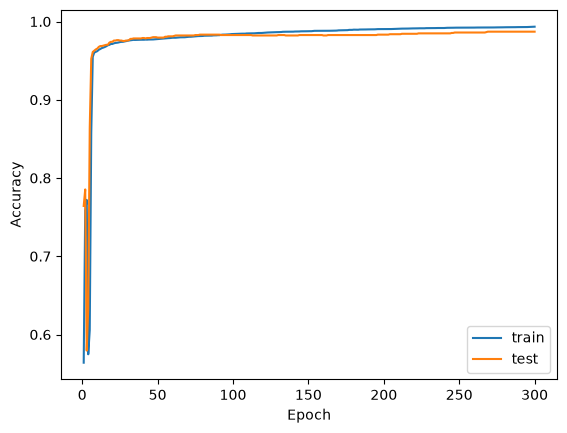

In [10]:
plt.plot(history["epoch"], history["train_acc"], label="train")
plt.plot(history["epoch"], history["test_acc"], label="test")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

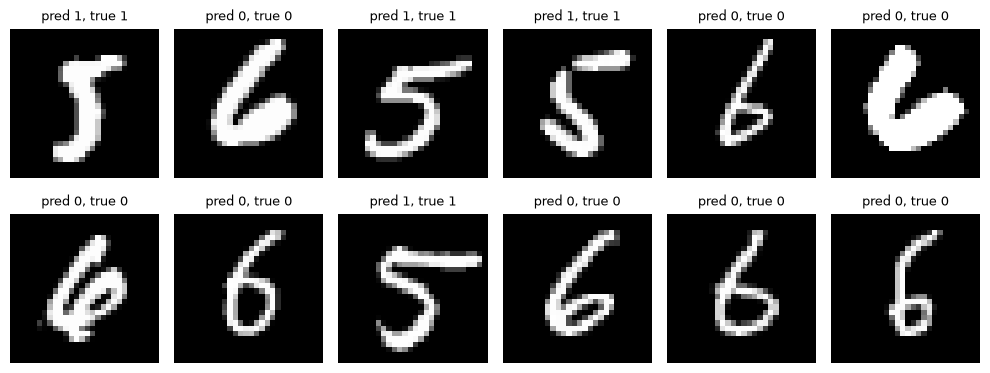

In [11]:
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    prob = test_pred[i].item()
    ax.imshow(X_test[i].view(28, 28), cmap="gray")
    ax.set_title(f"pred {int(prob >= 0.5)}, true {int(y_test[i].item())}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()